[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allison-diebol/open-iris/blob/main/colab/internals/03_geometry.ipynb)

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Geometry Nodes Documentation</strong></center>
</div>

---

This notebook covers the `geometry` step, and it's done through the nodes `iris.nodes.geometry_estimation` and `iris.nodes.eye_properties_estimation`. From it you will learn how to:

- Estimate the orientation of the iris using the Moment of Area method.
- Compute the center of the pupil and iris using the Bisectors Method.
- Extrapolate incomplete iris and pupil boundaries using Fusion Extrapolation.
- Understand the difference between circular (LinearExtrapolation) and elliptical (LSQEllipseFitWithRefinement) fitting methods.
- Handle occlusions by reconstructing missing parts of iris geometry.
- Validate that detected eye centers lie within acceptable image boundaries.
- Visualize geometric features such as orientation angles, center points, and reconstructed polygons.

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Moment of Area</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: eye_orientation</font>
    algorithm:    
      class_name: <font color='blue'>iris.MomentOfArea</font>
      params: {}
    inputs:
      - name: geometries
        source_node: distance_filter
    callbacks:

### What it does
Uses a mathematical property of the iris polygon called "moment of area" to calculate the horizontal orientation of the iris. If we represent an iris as an ellipse, this is equivalent to finding the angle of the major axis.

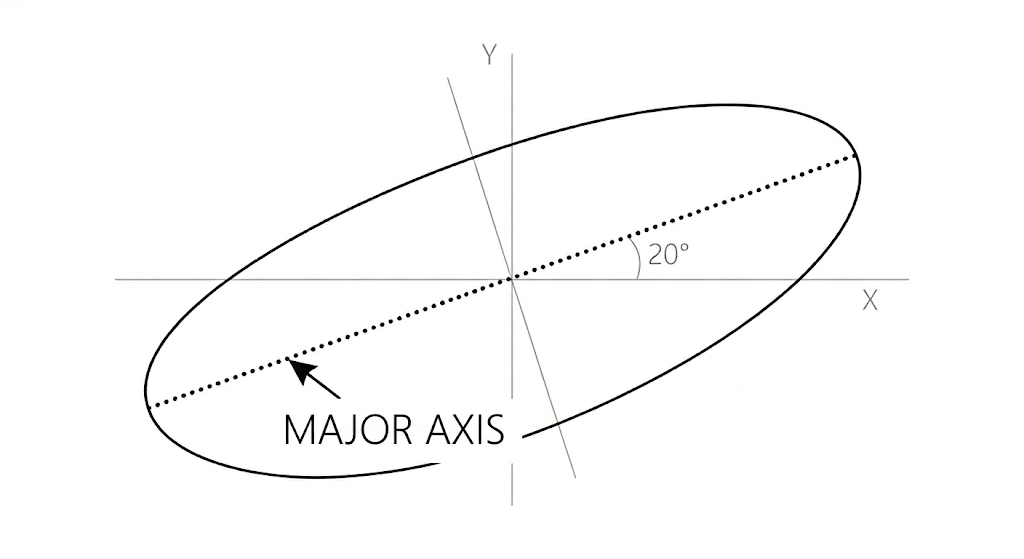

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `eccentricity_threshold` | `float in [0, 1]` | 0.1 | threshold below which an error should be thrown because the eye is too circuar to reliably calculate the orientation |

**Implementation Details**

Calls an OpenCV2 function cv2.moments that returns a dictionary with all the calculated moment values. Essentially, this is information that can be used to calculate the orientation of the image. Then calculates the eccentricity of the iris using these moments and makes sure the image is elliptical enough to get a reliable estimate of the orientation. Finally, calculates this orientation using a helper function from iris.utils.math. Returns this angle in the form of an EyeOrientation object, which just holds an angle in [-pi/2, pi/2).

**Code and visualizations**

In [15]:
# ---- Imports ----
import cv2
import iris
from pathlib import Path
from iris.nodes.eye_properties_estimation.moment_of_area import MomentOfArea

# ---- Load image ----
notebook_dir = Path.cwd() # Get the current working directory (the folder where the notebook is running)

# Go up one level to the colab folder
img_path = notebook_dir.parent / "sample_ir_image.png"

img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
geometries = pipeline.call_trace.get("distance_filter")

print("geometry polygons type:", type(geometries))

# Run MomentOfArea in isolation
node = MomentOfArea(eccentricity_threshold=0.1)

result = node.run(
    geometries=geometries
)

print("\nResult type:", type(result))
print("Eye orientation angle (in radians):", result.angle) 

geometry polygons type: <class 'iris.io.dataclasses.GeometryPolygons'>

Result type: <class 'iris.io.dataclasses.EyeOrientation'>
Eye orientation angle (in radians): -0.09534847229174304


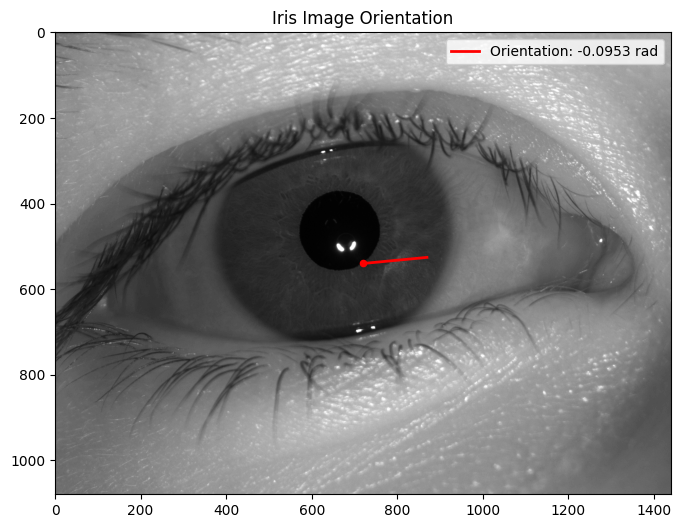

In [17]:
# ---- Imports ----
import matplotlib.pyplot as plt
import numpy as np

# Display the IR image
plt.figure(figsize=(10, 6))
plt.imshow(img_pixels, cmap='gray')

# Calculate the center of the image to start the orientation line
height, width = img_pixels.shape
cx, cy = width // 2, height // 2

# Define the line length for visualization
line_length = 150 

# result.angle is in radians; calculate the endpoint coordinates
end_x = cx + line_length * np.cos(result.angle)
end_y = cy + line_length * np.sin(result.angle)

# Plot the orientation line
plt.plot([cx, end_x], [cy, end_y], color='red', linewidth=2, label=f'Orientation: {result.angle:.4f} rad')
plt.scatter(cx, cy, color='red', s=20)  # Mark the center point

plt.title("Iris Image Orientation")
plt.legend()
plt.axis('on')
plt.show()

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Bisectors Method</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: eye_center_estimation</font>
    algorithm:    
      class_name: <font color='blue'>iris.BisectorsMethod</font>
      params: {}
    inputs:
      - name: geometries
        source_node: distance_filter
    callbacks:

### What it does

Algorithm used to estimate the center of the eye (i.e. the center of the pupil) using the perpendicular bisectors method for finding the center of a circle. The algorithm works as follows: pick 2 points on the edge of the circle, connect them with a line segment, find the perpendicular bisector of this line segment. Then repeat this for other pairs of 2 points. Finally, the intersection of all these bisectors gives an accurate estimate of the circle's center.

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `num_bisectors` | `int` | 100 | number of bisectors generated |
| `min_distance_between_sector_points` | `float` | 0.75 | Makes sure that the pairs of points whose perp bisector is being calculated are not too close. (The calculated bisector of a pair of points that is too close is highly sensitive to noise.) |
| `max_iterations` | `int` | 50 |  Max number of iterations during the algorithm that finds a perpendicular bisector given two points|


**Implementation Details**

There are three helper functions. _find_best_intersection does the final work of finding the approximate intersection of all the perpendicular bisector lines. The resulting point is BisectorsMethod's estimate of the center of the circle. _calculate_perpendicular_bisectors takes a numpy ndarray representing the vertices of the image of an iris and randomly chooses a bunch of pairs of vertices and finds the perpendicular bisectors of the line segment connecting these vertices. Finally, _find_center_coords uses these two previous helper functions to calculate the estimated center of a numpy array representing the vertices. 

The main run function calls _find_center_coords on the pupil array and the iris array, finding the estimated centers for both. The returned object is called "EyeCenters" and stores four values: pupil_x, pupil_y, iris_x, iris_y that give the (x,y) coords of the pupil and iris

### Code and visualizations

In [19]:
# ---- Imports ----
from iris.nodes.eye_properties_estimation.bisectors_method import BisectorsMethod

# ---- Pull intermediate outputs from call_trace ----
geometries = pipeline.call_trace.get("distance_filter")

print("geometries type:", type(geometries))

node = BisectorsMethod(num_bisectors=100, 
                       min_distance_between_sector_points=0.75, 
                       max_iterations=50)

result = node.run(
    geometries=geometries
)

print("\nResult type:", type(result))
print(f"Pupil center coords: ({result.pupil_x}, {result.pupil_y})")
print(f"Iris center coords: ({result.iris_x}, {result.iris_y})")

geometries type: <class 'iris.io.dataclasses.GeometryPolygons'>

Result type: <class 'iris.io.dataclasses.EyeCenters'>
Pupil center coords: (665.7943711373363, 465.38679231389176)
Iris center coords: (651.7241814133782, 466.47142974579623)


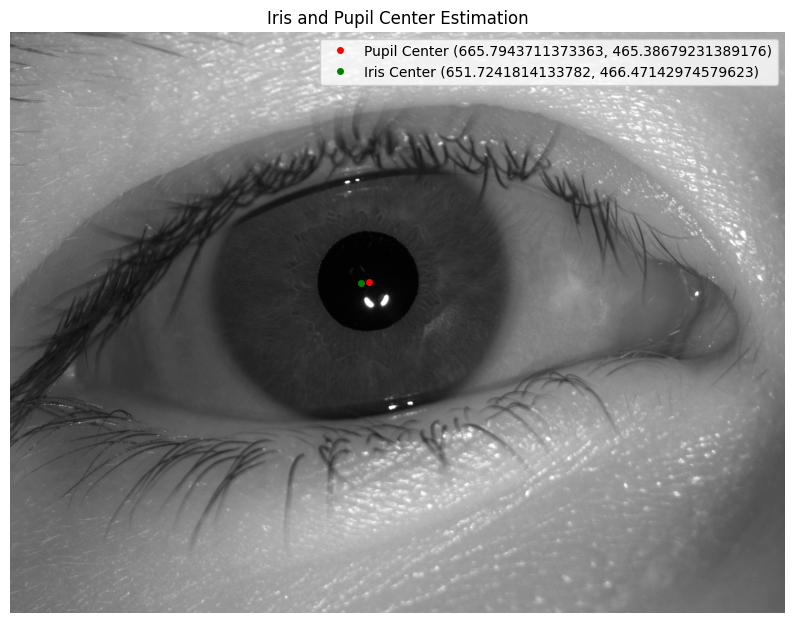

In [21]:
pupil_center = (result.pupil_x, result.pupil_y)
iris_center = (result.iris_x, result.iris_y)

# --- Plotting ---
plt.figure(figsize=(10, 8))
plt.imshow(img_pixels, cmap='gray')

plt.plot(pupil_center[0], pupil_center[1], 'ro', markersize=4, label=f'Pupil Center {pupil_center}')
plt.plot(iris_center[0], iris_center[1], 'go', markersize=4, label=f'Iris Center {iris_center}')

plt.title("Iris and Pupil Center Estimation")
plt.legend(loc='upper right')
plt.axis('off')
plt.show()

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>FusionExtrapolation</strong></center>
</div>

---

Example from pipeline.yaml
 
<code> - <font color='green'>name: geometry_estimation</font>
    algorithm:    
      class_name: <font color='blue'>iris.FusionExtrapolation</font>
      params:
        circle_extrapolation:
          class_name: iris.LinearExtrapolation
          params:
            dphi: 0.703125
        ellipse_fit:
          class_name: iris.LSQEllipseFitWithRefinement
          params:
            dphi: 0.703125
        algorithm_switch_std_threshold: 0.014
        algorithm_switch_std_conditioned_multiplier: 2.0
    inputs:
      - name: input_polygons
        source_node: smoothing
      - name: eye_center
        source_node: eye_center_estimation
    callbacks:

### What it does

Does extrapolation, i.e. filling in missing iris parts that have been occluded by something. FusionExtrapolation in particular uses two strategies, circle-like extrapolation (LinearExtrapolation Python class) and ellipse-like extrapolation (LSQEllipseFitWithRefinement Python class). FusionExtrapolation picks which strategy to use by estimating how circular the iris is. It does this by calculating the distance between points on the iris edge and points on the pupil edge and seeing how much these distances vary. The idea is that if the iris and pupil are perfectly circular, the variance will be zero whereas if they are more elliptical, the variance will be higher.

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `circle_extrapolation` | `Algorithm` | LinearExtrapolation(dphi=360 / 512) | algorithm to do extrapolation assuming the shape of the iris is circular. This will never be changed from the default argument since no other algorithm for circle extrapolation other than LinearExtrapolation has been implemented|
| `ellipse_fit` | `Algorithm` | LSQEllipseFitWithRefinement(dphi=360 / 512) |algorithm to do extrapolation assuming the shape of the iris is elliptical |
| `algorithm_switch_std_threshold:` | `float` | 0.014 | threshold for determining whether to use circular or elliptical extrapolation. The higher the threshold, the more bias towards circular extrapolation since a low standard deviation (std) of radii lengths corresponds to a circular shape.|
| `algorithm_switch_std_conditioned_multiplier:` | `float` | 2.0 | another way to control bias. The higher the multiplier here, the more bias towards using elliptical extrapolation.|
**Implementation details**

There are two helper functions: _relative_std and _squared_relative_radii. _relative_std takes a numpy array and simply returns its normalized standard deviation, ie std / mean. _squared_relative_radii takes two numpy arrays of size (N,2) representing the iris polygon and pupil polygons (so for example each row in the iris array will be a 2D point on the edge of the iris) and returns the "squared relative radii." This is an (N,1) array. The nth entry in this array gives you information about how far the nth point in the iris polygon is from the nth point in the pupil polygon. So if the iris and pupil are both perfectly circular, this will be an array of very small numbers and if one or both is elliptical, this will be an array of larger numbers. 

The run function calculates the radius standard deviation individually for both the iris and pupil polygon arrays. If either is elliptical (exceeds the threshold set by the user), it returns the extrapolated version of the polygon calculated using LSQEllipseFitWithRefinement). Otherwise, returns extrapolated polygon using circular extrapolation.

### Code and visualizations

In [23]:
# ---- Imports ----
from iris.nodes.geometry_estimation.fusion_extrapolation import FusionExtrapolation
from iris.nodes.geometry_estimation.linear_extrapolation import LinearExtrapolation
from iris.nodes.geometry_estimation.lsq_ellipse_fit_with_refinement import LSQEllipseFitWithRefinement

# ---- Pull intermediate outputs from call_trace ----
input_polygons = pipeline.call_trace.get("smoothing")
eye_center = pipeline.call_trace.get("eye_center_estimation")

print("input_polygons type:", type(input_polygons))
print("eye_center type:", type(eye_center))

linear_extrapolation = LinearExtrapolation(dphi=360/400)
ellipse_fit = LSQEllipseFitWithRefinement(dphi=360/400)

node = FusionExtrapolation(
    circle_extrapolation=linear_extrapolation,
    ellipse_fit=ellipse_fit,
    algorithm_switch_std_threshold=0.014,
    algorithm_switch_std_conditioned_multiplier=2
)

result = node.run(
    input_polygons=input_polygons,
    eye_center=eye_center
)

print("\nResult type:", type(result))

input_polygons type: <class 'iris.io.dataclasses.GeometryPolygons'>
eye_center type: <class 'iris.io.dataclasses.EyeCenters'>

Result type: <class 'iris.io.dataclasses.GeometryPolygons'>


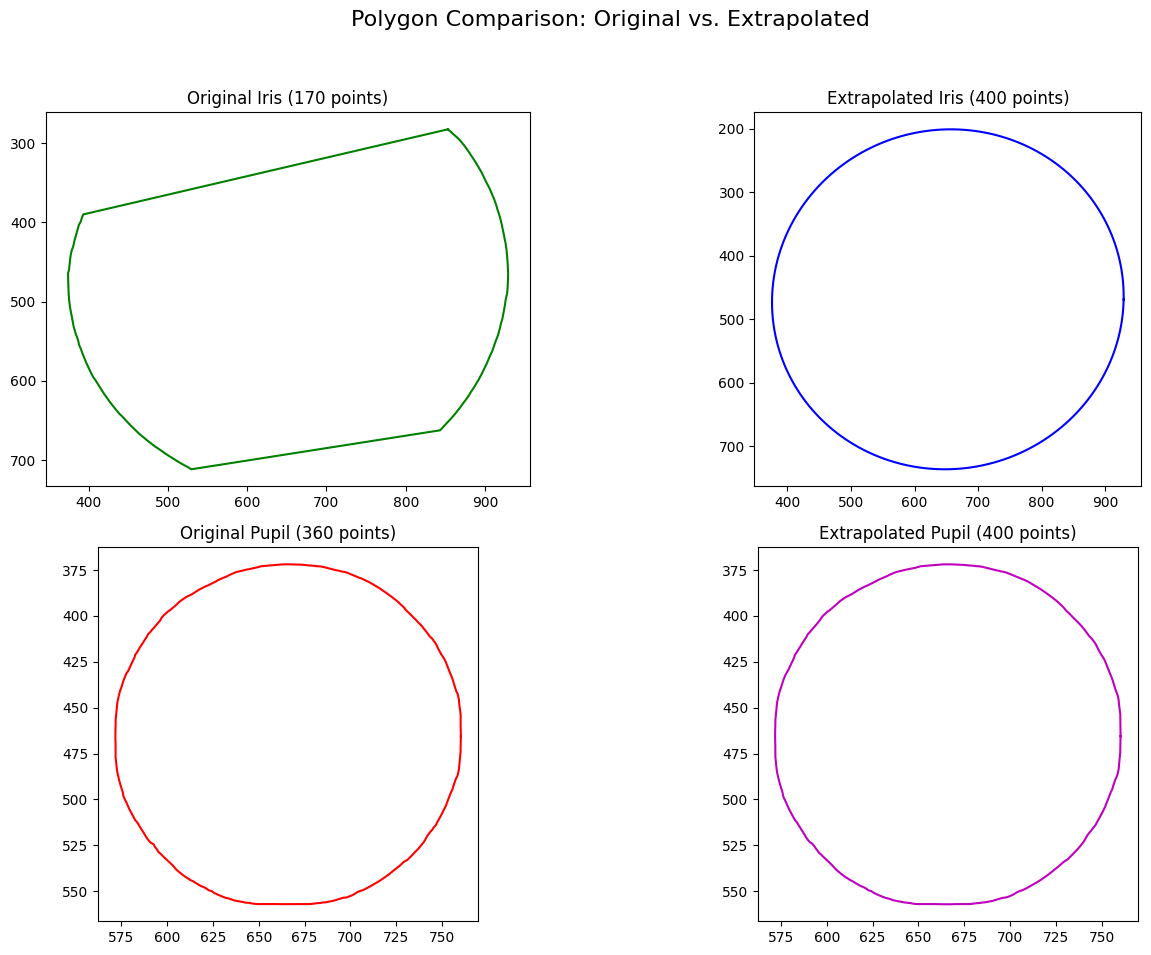

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper function to ensure the polygon is closed for plotting
def get_closed_poly(poly_vertices):
    return np.vstack([poly_vertices, poly_vertices[0]])

# --- Iris Comparison (Top Row) ---
# Original Iris
iris_orig = get_closed_poly(input_polygons.iris_array)
axes[0, 0].plot(iris_orig[:, 0], iris_orig[:, 1], 'g-', linewidth=1.5)
axes[0, 0].set_title(f"Original Iris ({len(input_polygons.iris_array)} points)")
axes[0, 0].invert_yaxis() # Match image coordinate system
axes[0, 0].set_aspect('equal')

# Extrapolated Iris
iris_extrap = get_closed_poly(result.iris_array)
axes[0, 1].plot(iris_extrap[:, 0], iris_extrap[:, 1], 'b-', linewidth=1.5)
axes[0, 1].set_title(f"Extrapolated Iris ({len(result.iris_array)} points)")
axes[0, 1].invert_yaxis()
axes[0, 1].set_aspect('equal')

# --- Pupil Comparison (Bottom Row) ---
# Original Pupil
pupil_orig = get_closed_poly(input_polygons.pupil_array)
axes[1, 0].plot(pupil_orig[:, 0], pupil_orig[:, 1], 'r-', linewidth=1.5)
axes[1, 0].set_title(f"Original Pupil ({len(input_polygons.pupil_array)} points)")
axes[1, 0].invert_yaxis()
axes[1, 0].set_aspect('equal')

# Extrapolated Pupil
pupil_extrap = get_closed_poly(result.pupil_array)
axes[1, 1].plot(pupil_extrap[:, 0], pupil_extrap[:, 1], 'm-', linewidth=1.5)
axes[1, 1].set_title(f"Extrapolated Pupil ({len(result.pupil_array)} points)")
axes[1, 1].invert_yaxis()
axes[1, 1].set_aspect('equal')

plt.suptitle("Polygon Comparison: Original vs. Extrapolated", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>LinearExtrapolation</strong></center>
</div>

---

Example from pipeline.yaml:

<code>   class_name: <font color='blue'>iris.LinearExtrapolation</font>
          params:
            dphi: 0.703125

### What it does

Does circular extrapolation to fill in missing parts of the iris polygon (perhaps caused by an obstruction while taking the photo, for example). The reason the word "linear" is used even though we're talking about circular objects is that coordinates are expressed in polar form, and circles are lines in polar coordinates. 

Takes as input the iris and pupil and eyeball polygons as well as their respective center points, and returns the iris and pupil and eyeball polygons with extrapolation complete

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `dphi` | `float` | 360/512 | Needs to be exactly num_pts_in_pupil_array / num_pts_in_iris_array|

**Implementation details**

There is only one helper function, _estimate, and it does essentially all the work. The run function simply calls _estimate on the pupil array and then on the iris array and returns the results. _estimate is given a numpy array containing vertices of a polygon (i.e. either the iris or pupil) and the center of the circle, and then it uses this to complete the circle. First it converts everything to polar coordinates, then it uses numpy to do linear interpolation, then it converts back to cartesian coordinates and returns the result

#### For demonstration of the algorithm on a test image, see above documentation on FusionExtrapolation

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>LSQEllipseFitWithRefinement</strong></center>
</div>

---

Example from pipeline.yaml:
    
<code>    class_name: <font color='blue'>iris.LSQEllipseFitWithRefinement</font>
          params:
            dphi: 0.703125

### What it does

Extrapolation algorithm that fills in missing parts of iris/pupil using the OpenCV method fitEllipse to fit an ellipse on iris and pupil polygons. Per the docstring,

Algorithm steps:

        1) Use OpenCV's fitEllipse method to fit an ellipse to predicted iris and pupil polygons.
        
        2) Refine predicted pupil polygons points to their original location to prevent location precision loss for those points which were predicted by semseg algorithm.

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `dphi` | `float` | 360/512 | Needs to be exactly num_pts_in_pupil_array / num_pts_in_iris_array|

**Implementation details**

There are four helper functions. parametric_ellipses takes the parameters that define an ellipse and returns an array of points in the ellipse. _find_correspondence takes two arrays, source and destination, and returns the index of the point in source that's closest to any of the destination points. _is_pupil_inide_iris_ellipses takes the defining characteristics of the fit pupil and iris ellipses (center, major and minor axis lengths) and quickly checks whether the pupil ellipse is fully inside the iris ellipse. 

The run function uses all these helper functions along with OpenCV's fitEllipse to fit an ellipse to the pupil and iris polygons and return the result

### For demonstration of the algorithm on a test image, see above documentation on FusionExtrapolation

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>EyeCentersInsideImageValidator</strong></center>
</div>

---

Example from pipeline.yaml:
    
<code> - <font color='green'>name: eye_centers_inside_image_validator</font>
    algorithm:
      class_name: <font color='blue'>iris.nodes.validators.cross_object_validators.EyeCentersInsideImageValidator</font> 
      params:
        min_distance_to_border: 0.0
    inputs:
      - name: ir_image
        source_node: input
      - name: eye_centers
        source_node: eye_center_estimation
    callbacks:

### What it does

Makes sure that the calculated eye center aren't too close to the edge of the image.

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `min_distance_to_border` | `float` | 0.0 | minimum allowed distance to border of image. So 0.0 means eye centers can be at the border. |

**Implementation details**

One helper function, _check_center_valid that returns a boolean denoting whether one eye center lies further than min_distance_to_border of the border. The run function then calls _check_center_valid on the pupil center and the iris center and raises an EyeCentersInsideImageValidatorError if they're too close to the border.

### Code and visualizations

In [27]:
from iris.nodes.validators.cross_object_validators import EyeCentersInsideImageValidator

# ---- Pull intermediate outputs from call_trace ----
eye_centers = pipeline.call_trace.get("eye_center_estimation")

print("ir_image type:", type(ir_image))
print("eye_centers type:", type(eye_center))

node = EyeCentersInsideImageValidator(min_distance_to_border=5)

result = node.run(
    ir_image=ir_image,
    eye_centers=eye_centers
)

# no error, so centers are further than 5 pixels from the border

ir_image type: <class 'iris.io.dataclasses.IRImage'>
eye_centers type: <class 'iris.io.dataclasses.EyeCenters'>
